In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from momentfm import MOMENTPipeline
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, precision_recall_curve, mean_squared_error, mean_absolute_error
import os
import matplotlib.pyplot as plt
import pandas as pd


D:\Учёба\Учёба ВШЭ\2 семестр\Курсач\.venv1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class DiffusionAEDataset(Dataset):
    def __init__(self, data_path, labels_path, window_size=512, step=1):
        self.data = np.load(data_path).astype(np.float32)
        self.labels = np.load(labels_path).astype(np.int64)

        if self.data.ndim == 1:
            self.data = self.data[:, np.newaxis]

        if self.labels.ndim == 2:
            self.labels = np.any(self.labels, axis=1).astype(np.int64)

        assert len(self.data) == len(self.labels), "Длина данных и меток не совпадает"

        self.window_size = window_size
        self.step = step
        self.indices = list(range(0, len(self.data) - window_size + 1, step))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        end = start + self.window_size

        x = self.data[start:end].T
        label = self.labels[start:end]

        x = torch.from_numpy(x)
        label = torch.from_numpy(label)
        input_mask = torch.ones(x.shape[1])

        return x, input_mask, label

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large",
    model_kwargs={"task_name": "reconstruction"}
)
model.init()
model = model.to(device).float()
model.eval()

MOMENTPipeline(
  (normalizer): RevIN()
  (tokenizer): Patching()
  (patch_embedding): PatchEmbedding(
    (value_embedding): Linear(in_features=8, out_features=1024, bias=False)
    (position_embedding): PositionalEmbedding()
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 1024)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=1024, out_features=1024, bias=False)
              (k): Linear(in_features=1024, out_features=1024, bias=False)
              (v): Linear(in_features=1024, out_features=1024, bias=False)
              (o): Linear(in_features=1024, out_features=1024, bias=False)
              (relative_attention_bias): Embedding(32, 16)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
  

In [4]:
samples_root = r"D:\Учёба\Учёба ВШЭ\2 семестр\Курсач\samples"
datasets = ["pattern_seasonal", "pattern_shapelet", "pattern_trendv2", "point_contextual", "point_global"]

window_size = 512
step = 32
batch_size = 16


In [5]:

def compute_metrics(labels_full, anomaly_scores):
    roc_auc = roc_auc_score(labels_full, anomaly_scores)
    precisions, recalls, thresholds = precision_recall_curve(labels_full, anomaly_scores)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]
    precision_opt = precisions[optimal_idx]
    recall_opt = recalls[optimal_idx]
    return {
        "roc_auc": roc_auc,
        "optimal_threshold": optimal_threshold,
        "optimal_f1": optimal_f1,
        "precision": precision_opt,
        "recall": recall_opt
    }

def aggregate_predictions(trues, preds, labels, dataset_indices, total_length, window_size):
    C = trues.shape[1]
    sum_trues = np.zeros((total_length, C))
    sum_preds = np.zeros((total_length, C))
    sum_labels = np.zeros(total_length)
    counts = np.zeros(total_length)

    for i, start in enumerate(dataset_indices):
        end = start + window_size
        sum_trues[start:end] += trues[i].T
        sum_preds[start:end] += preds[i].T
        sum_labels[start:end] += labels[i]
        counts[start:end] += 1

    trues_full = sum_trues / counts[:, np.newaxis]
    preds_full = sum_preds / counts[:, np.newaxis]
    labels_full = np.round(sum_labels / counts).astype(int)
    anomaly_scores = np.mean((trues_full - preds_full) ** 2, axis=1)
    return trues_full, preds_full, labels_full, anomaly_scores

In [6]:
# Сбор результатов
results_list = []
all_anomaly_scores = {}   # для сохранения скорей (опционально)

for ds_name in datasets:
    print(f"Обработка {ds_name}...")
    data_dir = os.path.join(samples_root, ds_name)
    test_data_path = os.path.join(data_dir, "test.npy")
    test_labels_path = os.path.join(data_dir, "labels.npy")

    if not os.path.exists(test_data_path) or not os.path.exists(test_labels_path):
        print(f"  Файлы не найдены, пропуск")
        continue

    # Датасет и загрузчик
    test_dataset = DiffusionAEDataset(test_data_path, test_labels_path, window_size=window_size, step=step)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # Инференс
    trues, preds, labels = [], [], []
    with torch.no_grad():
        for batch_x, batch_masks, batch_labels in tqdm(test_loader, desc=f"  Inference {ds_name}", leave=False):
            batch_x = batch_x.to(device)
            batch_masks = batch_masks.to(device)
            output = model(x_enc=batch_x, input_mask=batch_masks)
            trues.append(batch_x.cpu().numpy())
            preds.append(output.reconstruction.cpu().numpy())
            labels.append(batch_labels.cpu().numpy())

    trues = np.concatenate(trues, axis=0)
    preds = np.concatenate(preds, axis=0)
    labels = np.concatenate(labels, axis=0)

    # Агрегация
    total_length = len(test_dataset.data)
    trues_full, preds_full, labels_full, anomaly_scores = aggregate_predictions(
        trues, preds, labels, test_dataset.indices, total_length, window_size
    )
    all_anomaly_scores[ds_name] = (anomaly_scores, labels_full)

    # Метрики
    metrics = compute_metrics(labels_full, anomaly_scores)
    trues_flat = trues_full.flatten()
    preds_flat = preds_full.flatten()
    rmse = np.sqrt(mean_squared_error(trues_flat, preds_flat))
    mae = mean_absolute_error(trues_flat, preds_flat)

    # Сохраняем в словарь для DataFrame
    results_list.append({
        "Dataset": ds_name,
        "ROC AUC": metrics["roc_auc"],
        "F1-score": metrics["optimal_f1"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "RMSE": rmse,
        "MAE": mae,
        "Optimal threshold": metrics["optimal_threshold"]
    })


Обработка pattern_seasonal...


Обработка pattern_shapelet...


Обработка pattern_trendv2...


Обработка point_contextual...


Обработка point_global...



Сводная таблица метрик по всем датасетам:
         Dataset  ROC AUC  F1-score  Precision   Recall     RMSE      MAE  Optimal threshold
pattern_seasonal 0.808545  0.605891   0.825478 0.478582 0.077005 0.061074           0.013299
pattern_shapelet 0.639282  0.343070   0.610586 0.238552 0.073509 0.058838           0.012626
 pattern_trendv2 0.745496  0.403304   0.561303 0.314715 0.079171 0.060714           0.013508
point_contextual 0.773041  0.491620   0.684292 0.383609 0.075037 0.059818           0.012629
    point_global 0.960501  0.780488   0.844670 0.725371 0.067477 0.052751           0.009577

Результаты сохранены в 'anomaly_detection_results.csv'


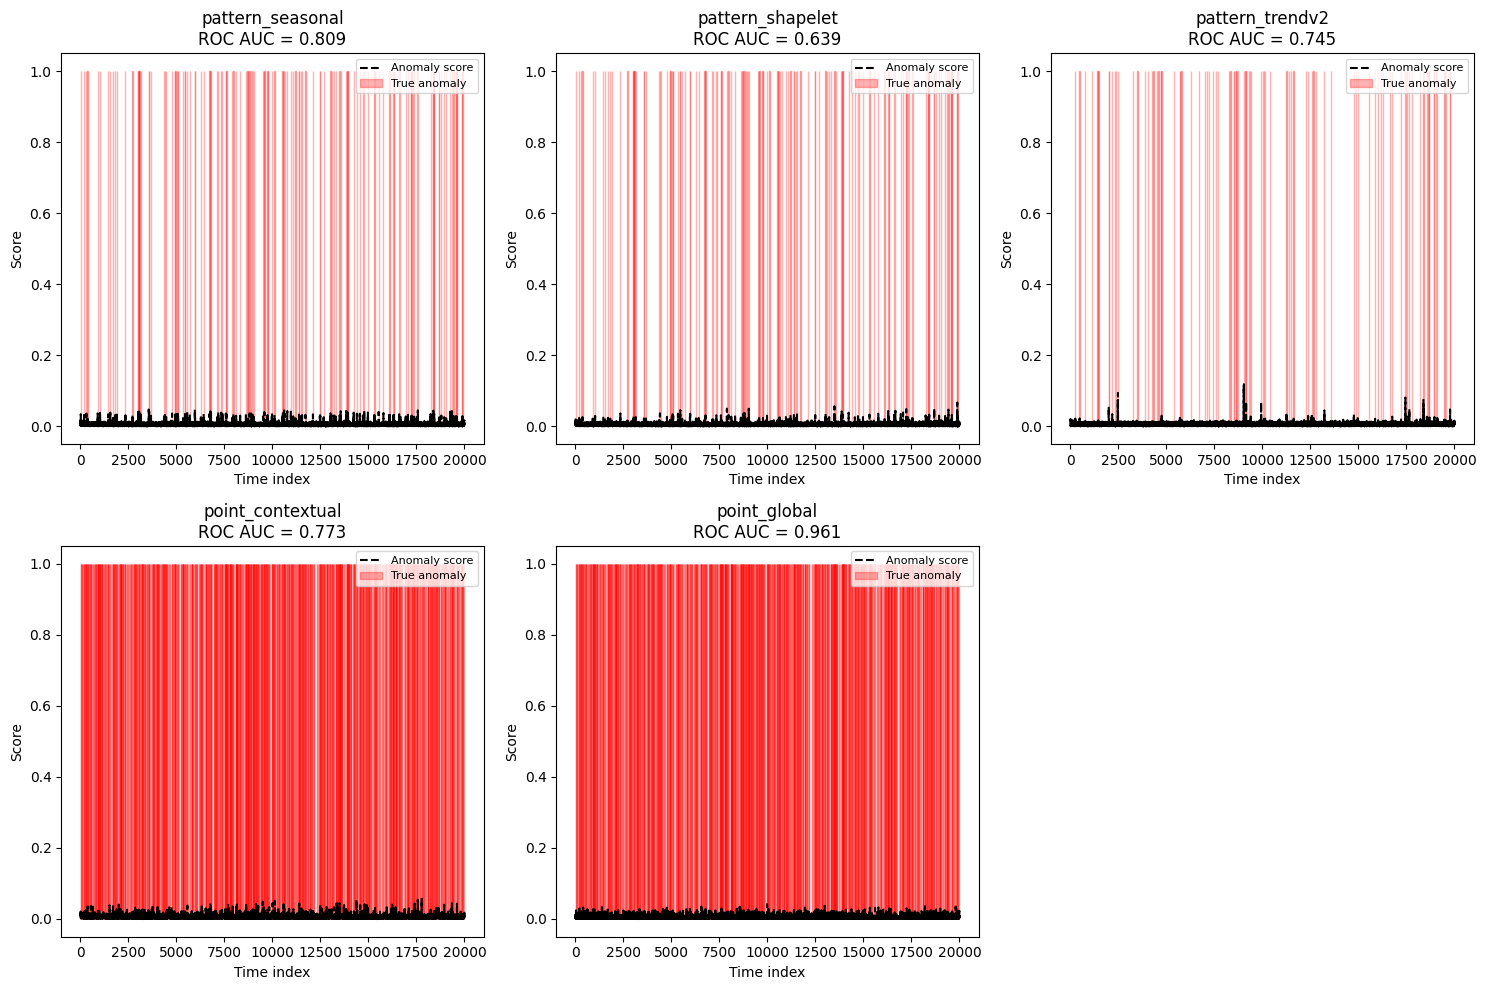

Общий график сохранён как 'all_datasets_anomaly_scores.png'


In [7]:
# Создание и вывод таблицы
df_results = pd.DataFrame(results_list)
print("\n" + "="*80)
print("Сводная таблица метрик по всем датасетам:")
print("="*80)
print(df_results.to_string(index=False))

# Сохраняем таблицу в CSV (опционально)
df_results.to_csv("anomaly_detection_results.csv", index=False)
print("\nРезультаты сохранены в 'anomaly_detection_results.csv'")

# Построение общего графика (subplots)
n_datasets = len(all_anomaly_scores)
if n_datasets > 0:
    # Определяем расположение subplots (2 строки, 3 столбца, но если 5, то 2x3)
    n_cols = 3
    n_rows = (n_datasets + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_datasets > 1 else [axes]

    for idx, (ds_name, (scores, lbls)) in enumerate(all_anomaly_scores.items()):
        ax = axes[idx]
        # Выбираем область для визуализации (аномалии ±512)
        anomaly_idx = np.where(lbls == 1)[0]
        if len(anomaly_idx) > 0:
            start = max(0, anomaly_idx[0] - 512)
            end = min(len(scores), anomaly_idx[-1] + 512)
        else:
            start, end = 0, len(scores)

        ax.plot(scores[start:end], color='black', linestyle='--', label='Anomaly score')
        ax.fill_between(range(end - start), 0, 1,
                         where=(lbls[start:end] == 1),
                         color='red', alpha=0.3, label='True anomaly')
        ax.set_title(f"{ds_name}\nROC AUC = {df_results.loc[idx, 'ROC AUC']:.3f}")
        ax.set_xlabel("Time index")
        ax.set_ylabel("Score")
        ax.legend(loc='upper right', fontsize=8)

    # Скрываем лишние оси
    for j in range(idx+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
    fig.savefig("all_datasets_anomaly_scores.png", dpi=150)